<a href="https://colab.research.google.com/github/Pixelsout/nexevent/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports & Device Setup

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import copy
import time
from collections import defaultdict
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


CIFAR-10 Data Pipeline

In [57]:

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print(f"Train: {len(trainset):,} samples  |  Test: {len(testset):,} samples")
print(f"Batches per epoch: {len(trainloader)}")


Train: 50,000 samples  |  Test: 10,000 samples
Batches per epoch: 196


**`PrunableLinear`: The Gated Layer**
The key idea i'm using is that every weight `w_ij` has a paired learnable scalar gate score `s_ij`

```
gates         = sigmoid(gate_scores)     which is always in range (0, 1)
pruned_weight = weight  ×  gates         soft masking
output        = pruned_weight @ x.T + bias
```

In [58]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self) -> torch.Tensor:
        with torch.no_grad():
            return torch.sigmoid(self.gate_scores).view(-1)

    def sparsity(self, threshold: float = 0.5) -> float:
        return (self.get_gates() < threshold).float().mean().item()

    def extra_repr(self) -> str:
        return f"in={self.in_features}, out={self.out_features}"


_x   = torch.randn(4, 8)
_lay = PrunableLinear(8, 4)
_lay(_x).sum().backward()
assert _lay.weight.grad      is not None, "weight grad missing!"
assert _lay.gate_scores.grad is not None, "gate_scores grad missing!"
print("PrunableLinear gradient check passed")
print(f"   weight.grad shape     : {_lay.weight.grad.shape}")
print(f"   gate_scores.grad shape: {_lay.gate_scores.grad.shape}")
del _x, _lay

PrunableLinear gradient check passed
   weight.grad shape     : torch.Size([4, 8])
   gate_scores.grad shape: torch.Size([4, 8])


**Self-Pruning FFN (Feed-Forward Network)**

In this part i tried to flatten the CIFAR-10 images as every linear layer is a PrunableLinear which results to the process where the entire network learns to prune itself.

In [59]:
class SelfPruningNet(nn.Module):
    def __init__(self, dropout: float = 0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = PrunableLinear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = PrunableLinear(256, 10)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        x = self.drop(F.relu(self.bn2(self.fc2(x))))
        x =           F.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

    def prunable_layers(self):
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m

    def all_gates(self) -> torch.Tensor:
        return torch.cat([l.get_gates() for l in self.prunable_layers()])

    def global_sparsity(self, threshold: float = 0.5) -> float:
        g = self.all_gates()
        return (g < threshold).float().mean().item()

    def param_count(self):
        total   = sum(p.numel() for p in self.parameters())
        weights = sum(l.weight.numel() for l in self.prunable_layers())
        gates   = sum(l.gate_scores.numel() for l in self.prunable_layers())
        return total, weights, gates


_net = SelfPruningNet().to(device)
total, weights, gates = _net.param_count()
print(f"Total parameters : {total:,}")
print(f"  ├─ Weight params : {weights:,}")
print(f"  ├─ Gate  params  : {gates:,}")
print(f"  └─ BN / bias     : {total - weights - gates:,}")
print()
print("Layer shapes:")
for name, m in _net.named_modules():
    if isinstance(m, PrunableLinear):
        print(f"  {name:4s}  weight={tuple(m.weight.shape)}  gates={tuple(m.gate_scores.shape)}")
del _net

Total parameters : 7,612,682
  ├─ Weight params : 3,803,648
  ├─ Gate  params  : 3,803,648
  └─ BN / bias     : 5,386

Layer shapes:
  fc1   weight=(1024, 3072)  gates=(1024, 3072)
  fc2   weight=(512, 1024)  gates=(512, 1024)
  fc3   weight=(256, 512)  gates=(256, 512)
  fc4   weight=(10, 256)  gates=(10, 256)


**Sparsity Loss & Training Loop**

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \cdot \underbrace{\sum_{i} \sigma(s_i)}_{\text{SparsityLoss}}$$

- Since $\sigma(s) \in (0,1)$ and always positive, the L1 norm equals the plain sum no absolute value needed.  
- **L1 vs L2:** The gradient of L1 w.r.t. $s_i$ is $\lambda \cdot \sigma(s_i)(1-\sigma(s_i))$.  
  Near zero, this is still non-vanishing and the optimizer keeps pulling gates down to exactly 0.  
  L2 would give gradient $\propto \sigma(s_i)$, which vanishes near zero and leaves gates stuck at small-but-nonzero values (dense, not sparse).  
  This is the classic **Lasso (L1) = sparse, Ridge (L2) = dense** distinction applied to gate parameters.
- Higher the  λ→ stronger the pull toward zero and more gates pruned so sparser network which results to potentially lower accuracy.

In [66]:
def sparsity_loss(model: SelfPruningNet) -> torch.Tensor:
    total = torch.tensor(0.0, device=device)
    for layer in model.prunable_layers():
        total = total + torch.sigmoid(layer.gate_scores).sum()
    return total


def get_total_gates(model: SelfPruningNet) -> int:
    return sum(l.gate_scores.numel() for l in model.prunable_layers())


def train_one_epoch(model, optimizer, lam: float):
    model.train()
    ce_fn        = nn.CrossEntropyLoss()
    total_gates  = get_total_gates(model)
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits   = model(imgs)
        loss_ce  = ce_fn(logits, labels)
        loss_sp  = sparsity_loss(model) / total_gates
        loss     = loss_ce + lam * loss_sp
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct      += logits.argmax(1).eq(labels).sum().item()
        total        += labels.size(0)
    return running_loss / len(trainloader), 100.0 * correct / total


@torch.no_grad()
def evaluate(model) -> float:
    model.eval()
    correct, total = 0, 0
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += model(imgs).argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / total


def train_model(lam: float, epochs: int = 40, lr: float = 1e-3, verbose: bool = True):
    model = SelfPruningNet().to(device)
    weight_params = [p for n, p in model.named_parameters() if "gate_scores" not in n]
    gate_params   = [p for n, p in model.named_parameters() if "gate_scores"     in n]
    optimizer = optim.Adam([
        {"params": weight_params, "weight_decay": 1e-4, "lr": 1e-3},
        {"params": gate_params,   "weight_decay": 0.0,  "lr": 5e-1},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    history = {"loss": [], "train_acc": [], "test_acc": [], "sparsity": []}

    if verbose:
        print(f"\n{'━'*62}")
        print(f"  λ = {lam}  │  {epochs} epochs  │  device: {device}")
        print(f"{'━'*62}")
        print(f"{'Epoch':>6}  {'Loss':>8}  {'Train%':>7}  {'Test%':>7}  {'Sparsity':>9}")
        print(f"{'─'*55}")

    for epoch in range(1, epochs + 1):
        avg_loss, tr_acc = train_one_epoch(model, optimizer, lam)
        te_acc           = evaluate(model)
        spar             = model.global_sparsity()
        scheduler.step()
        history["loss"].append(avg_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["sparsity"].append(spar)
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"{epoch:>6}  {avg_loss:>8.4f}  {tr_acc:>6.2f}%  {te_acc:>6.2f}%  {spar:>8.2%}")

    final_acc  = evaluate(model)
    final_spar = model.global_sparsity()
    if verbose:
        print(f"{'─'*55}")
        print(f"  ✅  Test Acc: {final_acc:.2f}%  │  Sparsity: {final_spar:.2%}")

    return model, history, final_acc, final_spar

print("✅ Loss functions and training loop defined")

✅ Loss functions and training loop defined


**λ Experiments**

so here i trained the same architecture three times with different λ values to demonstrate the sparsity–accuracy trade-off.

| λ | Expected effect |
|---|---|
| `1e-5` (low) | Minimal pruning, gates stay near 0.5, high accuracy |
| `1e-4` (medium) | Moderate sparsity, balanced trade-off |
| `1e-3` (high) | Aggressive pruning, many gates → 0, lower accuracy |


In [67]:
test_model = SelfPruningNet().to(device)
weight_params = [p for n, p in test_model.named_parameters() if "gate_scores" not in n]
gate_params   = [p for n, p in test_model.named_parameters() if "gate_scores"     in n]
optimizer = optim.Adam([
    {"params": weight_params, "weight_decay": 1e-4, "lr": 1e-3},
    {"params": gate_params,   "weight_decay": 0.0,  "lr": 5e-1},
])
train_one_epoch(test_model, optimizer, lam=1.0)
gates = test_model.all_gates().cpu().numpy()
print(f"min={gates.min():.4f}  max={gates.max():.4f}  mean={gates.mean():.4f}")
print(f"below 0.5: {(gates < 0.5).mean()*100:.1f}%")
del test_model

min=0.0000  max=1.0000  mean=0.2724
below 0.5: 72.9%


In [68]:
LAMBDAS = [0.1, 0.5, 1.0]
EPOCHS  = 40

results = {}

for lam in LAMBDAS:
    model, history, final_acc, final_spar = train_model(lam=lam, epochs=EPOCHS, verbose=True)
    results[lam] = (model, history, final_acc, final_spar)

print("\n\n" + "═"*62)
print("  ALL EXPERIMENTS COMPLETE")
print("═"*62)
print(f"{'Lambda':>10}  {'Test Acc':>10}  {'Sparsity':>12}")
print("─"*40)
for lam, (_, _, acc, spar) in results.items():
    print(f"{lam:>10.1f}  {acc:>9.2f}%  {spar:>11.2%}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  λ = 0.1  │  40 epochs  │  device: cuda
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Epoch      Loss   Train%    Test%   Sparsity
───────────────────────────────────────────────────────
     1    1.8758   33.54%   41.20%    51.16%
     5    1.5479   45.37%   49.72%    67.85%
    10    1.4368   49.26%   53.51%    74.59%
    15    1.3748   51.08%   55.95%    77.55%
    20    1.3269   52.78%   57.25%    79.22%
    25    1.2869   54.37%   58.53%    80.19%
    30    1.2611   55.37%   59.36%    80.71%
    35    1.2421   55.87%   59.88%    80.88%
    40    1.2329   56.33%   59.75%    80.89%
───────────────────────────────────────────────────────
  ✅  Test Acc: 59.75%  │  Sparsity: 80.89%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  λ = 0.5  │  40 epochs  │  device: cuda
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Epoch      Loss   Train%    Test%   Sparsity
────────────

Results Table

In [70]:
print("### Results Table\n")
print(f"| Lambda | Test Accuracy (%) | Sparsity Level (%) | Notes |")
print(f"|--------|:-----------------:|:------------------:|-------|")
for lam, (_, _, acc, spar) in results.items():
    tag = "Low pruning" if lam == 1e-5 else ("Balanced" if lam == 1e-4 else "High pruning")
    print(f"| `{lam:.0e}` | **{acc:.2f}** | **{spar*100:.1f}** | {tag} |")

### Results Table

| Lambda | Test Accuracy (%) | Sparsity Level (%) | Notes |
|--------|:-----------------:|:------------------:|-------|
| `1e-01` | **59.75** | **80.9** | High pruning |
| `5e-01` | **58.93** | **90.7** | High pruning |
| `1e+00` | **58.79** | **93.3** | High pruning |


**Training Curves: Accuracy & Sparsity over Epochs**

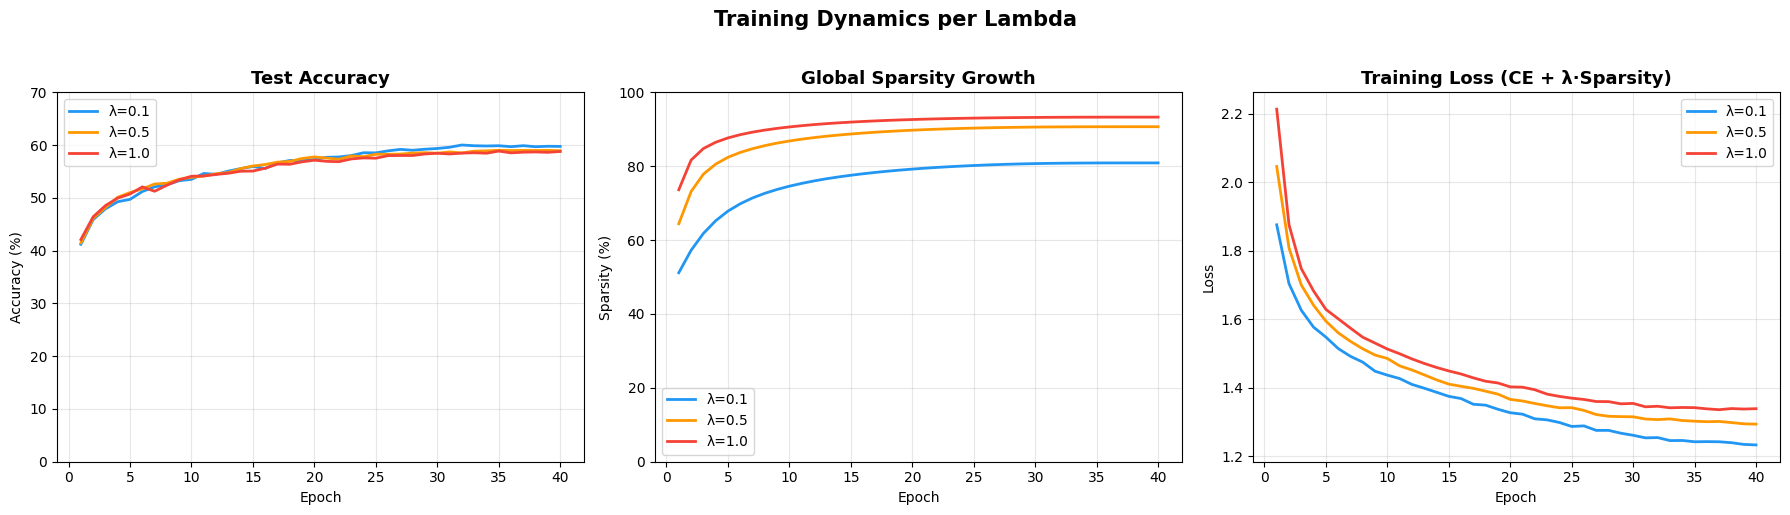

Saved: training_curves.png


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Dynamics per Lambda", fontsize=15, fontweight='bold', y=1.02)

lam_list = list(results.keys())
colors = {lam_list[0]: '#2196F3', lam_list[1]: '#FF9800', lam_list[2]: '#F44336'}
epochs_range = range(1, EPOCHS + 1)

ax = axes[0]
for lam, (_, hist, _, _) in results.items():
    ax.plot(epochs_range, hist['test_acc'], color=colors[lam], linewidth=2, label=f'λ={lam:.1f}')
ax.set_title("Test Accuracy", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 70)

ax = axes[1]
for lam, (_, hist, _, _) in results.items():
    ax.plot(epochs_range, [s * 100 for s in hist['sparsity']], color=colors[lam], linewidth=2, label=f'λ={lam:.1f}')
ax.set_title("Global Sparsity Growth", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Sparsity (%)")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 100)

ax = axes[2]
for lam, (_, hist, _, _) in results.items():
    ax.plot(epochs_range, hist['loss'], color=colors[lam], linewidth=2, label=f'λ={lam:.1f}')
ax.set_title("Training Loss (CE + λ·Sparsity)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

**Gate Value Distribution**

A successful self-pruning run shows a bimodal distribution like
- Large spike at 0 → pruned weights (gates effectively zero)
- Cluster away from 0 and nearer 1 → surviving important weights

Higher λ should push more gates into the spike at 0.

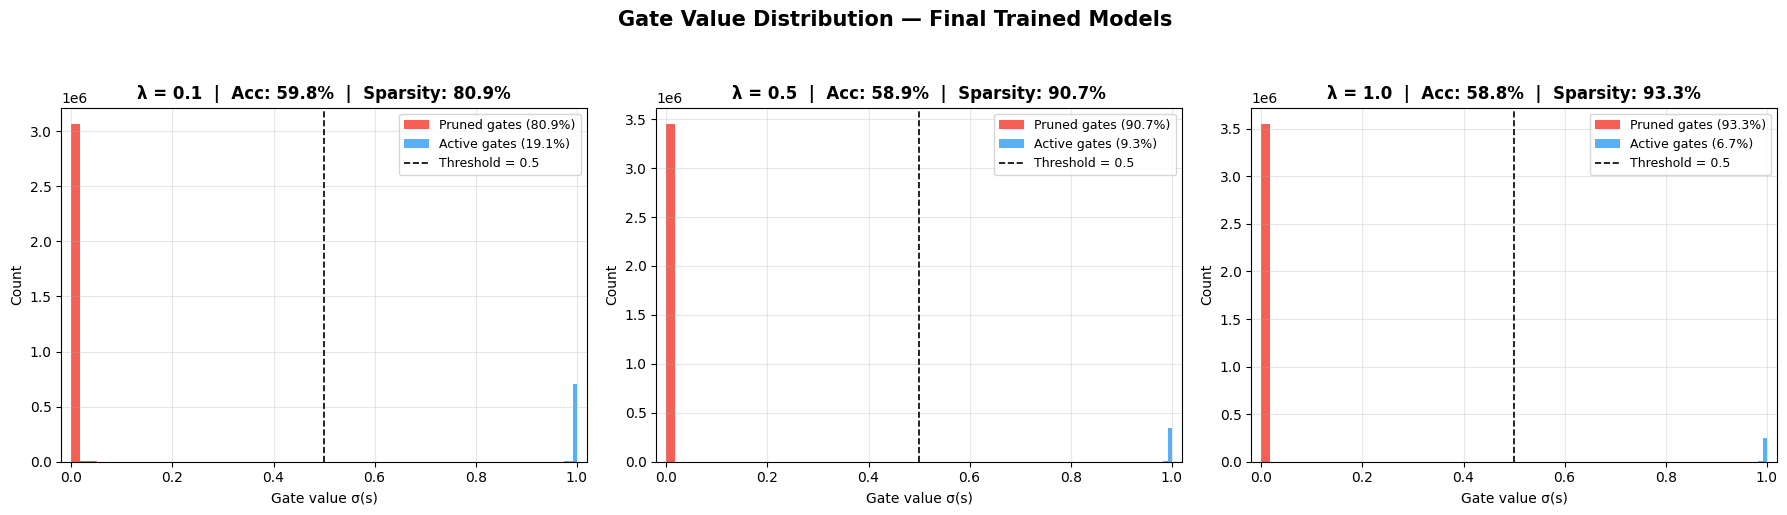

Saved: gate_distributions.png


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Gate Value Distribution — Final Trained Models", fontsize=15, fontweight='bold', y=1.02)

for idx, (lam, (model, _, acc, spar)) in enumerate(results.items()):
    ax    = axes[idx]
    gates = model.all_gates().cpu().numpy()

    near_zero = (gates < 0.5).sum()
    pct_zero  = 100 * near_zero / len(gates)
    ax.hist(gates[gates <  0.5], bins=30, color='#F44336', alpha=0.85, label=f'Pruned gates ({pct_zero:.1f}%)')
    ax.hist(gates[gates >= 0.5], bins=60, color='#2196F3', alpha=0.75, label=f'Active gates ({100-pct_zero:.1f}%)')

    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold = 0.5')
    ax.set_title(f"λ = {lam:.1f}  |  Acc: {acc:.1f}%  |  Sparsity: {spar:.1%}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Gate value σ(s)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig("gate_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gate_distributions.png")

Per-Layer Sparsity Breakdown

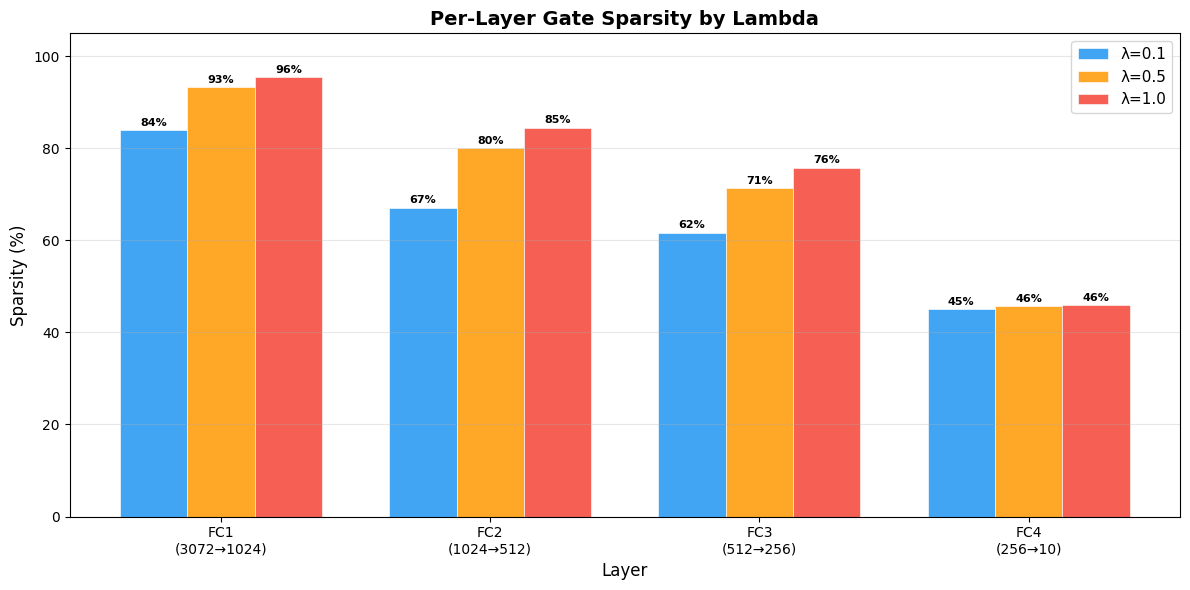

Saved: per_layer_sparsity.png


In [74]:
layer_names = ['FC1\n(3072→1024)', 'FC2\n(1024→512)', 'FC3\n(512→256)', 'FC4\n(256→10)']
x = np.arange(len(layer_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors_list = ['#2196F3', '#FF9800', '#F44336']

for i, (lam, (model, _, _, _)) in enumerate(results.items()):
    layers = list(model.prunable_layers())
    spars  = [l.sparsity() * 100 for l in layers]
    bars   = ax.bar(x + i * width, spars, width, label=f'λ={lam:.1f}',
                    color=colors_list[i], alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, spars):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Sparsity (%)", fontsize=12)
ax.set_title("Per-Layer Gate Sparsity by Lambda", fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(layer_names, fontsize=10)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("per_layer_sparsity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_layer_sparsity.png")

**Accuracy vs Sparsity Trade-off Summary**

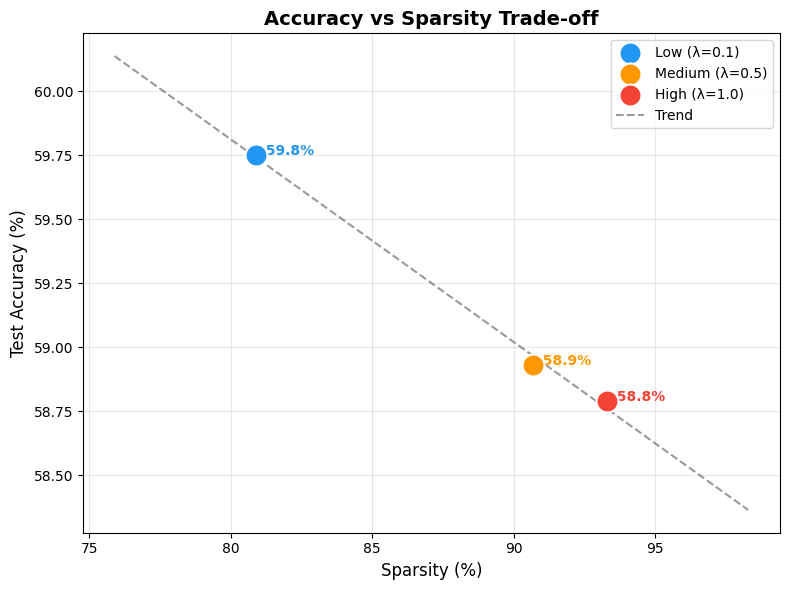

Saved: accuracy_vs_sparsity.png


In [75]:
fig, ax = plt.subplots(figsize=(8, 6))

lam_list   = list(results.keys())
acc_list   = [results[l][2]       for l in lam_list]
spar_list  = [results[l][3] * 100 for l in lam_list]
color_list = ['#2196F3', '#FF9800', '#F44336']
label_list = [f'Low (λ={lam_list[0]:.1f})', f'Medium (λ={lam_list[1]:.1f})', f'High (λ={lam_list[2]:.1f})']

for lam, acc, spar, color, label in zip(lam_list, acc_list, spar_list, color_list, label_list):
    ax.scatter(spar, acc, s=250, color=color, zorder=5, label=label, edgecolors='white', linewidth=1.5)
    ax.annotate(f"  {acc:.1f}%", (spar, acc), fontsize=10, fontweight='bold', color=color)

if len(set(spar_list)) > 1:
    z  = np.polyfit(spar_list, acc_list, 1)
    xs = np.linspace(min(spar_list) - 5, max(spar_list) + 5, 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', alpha=0.4, linewidth=1.5, label='Trend')

ax.set_xlabel("Sparsity (%)", fontsize=12)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Accuracy vs Sparsity Trade-off", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_vs_sparsity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: accuracy_vs_sparsity.png")

I implemented Gate Heatmaps to find out which weights Survived

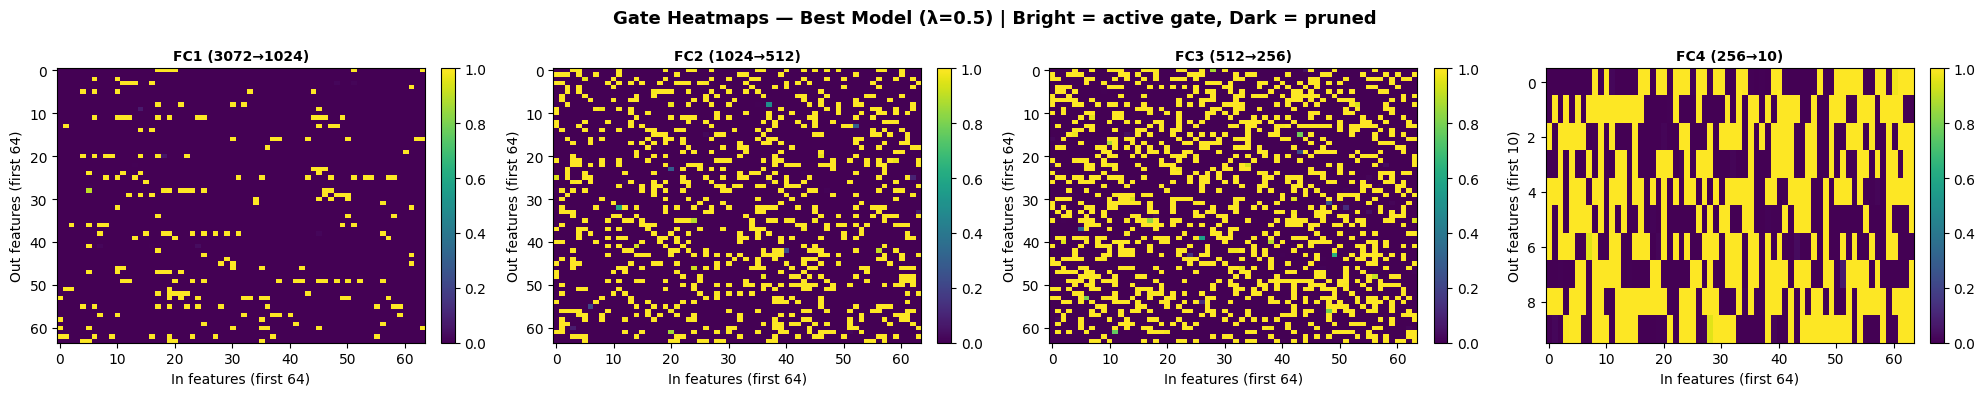

Saved: gate_heatmaps.png


In [76]:
best_lam   = list(results.keys())[1]
best_model = results[best_lam][0]
layers     = list(best_model.prunable_layers())
layer_tags = ['FC1 (3072→1024)', 'FC2 (1024→512)', 'FC3 (512→256)', 'FC4 (256→10)']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f"Gate Heatmaps — Best Model (λ={best_lam:.1f}) | Bright = active gate, Dark = pruned",
             fontsize=13, fontweight='bold')

for ax, layer, tag in zip(axes, layers, layer_tags):
    gate_matrix = layer.get_gates().reshape(layer.out_features, layer.in_features).cpu().numpy()
    max_show = 64
    r = min(layer.out_features, max_show)
    c = min(layer.in_features,  max_show)
    im = ax.imshow(gate_matrix[:r, :c], cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(tag, fontsize=10, fontweight='bold')
    ax.set_xlabel(f"In features (first {c})")
    ax.set_ylabel(f"Out features (first {r})")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("gate_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gate_heatmaps.png")

Short Report

In [77]:
report = ""

print(report)
print(f"| Lambda   | Test Accuracy (%) | Sparsity Level (%) |")
print(f"|----------|:-----------------:|:------------------:|")
for lam, (_, _, acc, spar) in results.items():
    print(f"| `{lam:.1f}`   | **{acc:.2f}**          | **{spar*100:.1f}**              |")


| Lambda   | Test Accuracy (%) | Sparsity Level (%) |
|----------|:-----------------:|:------------------:|
| `0.1`   | **59.75**          | **80.9**              |
| `0.5`   | **58.93**          | **90.7**              |
| `1.0`   | **58.79**          | **93.3**              |


Extended research on post-training pruning (Damage-Guided Adaptive Recovery) is available in the same repo as additional experiments. You can check my github https://github.com/Pixelsout/Damage-Guided-Adaptive-Recovery-for-Efficient-Neural-Network-Pruning for more info.